In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import proplot as pplt

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

In [2]:
basedir='/data/esplab/kpegion/projects/AGCM_Experiments/'
cntrl_exp='T63L26_JJA_1979-2023'
#expnames=['T63L26_JJA_Cluster1_ANA_1979-2023','T63L26_JJA_Cluster2_ANA_1979-2023',
#          'T63L26_JJA_Cluster3_ANA_1979-2023','T63L26_JJA_Cluster4_ANA_1979-2023']
expnames=['T63L26_JJA_Cluster1_SE','T63L26_JJA_Cluster2_SE',
         'T63L26_JJA_Cluster3_SE','T63L26_JJA_Cluster4_SE']

fname='vvel_Pressure_days_1-60.nc'

/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 1.21.5)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Reading: /data/esplab/kpegion/projects/AGCM_Experiments/T63L26_JJA_Cluster1_SE/vvel_Pressure_days_1-60.nc


/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:406: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


Reading: /data/esplab/kpegion/projects/AGCM_Experiments/T63L26_JJA_Cluster2_SE/vvel_Pressure_days_1-60.nc


/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:406: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


Reading: /data/esplab/kpegion/projects/AGCM_Experiments/T63L26_JJA_Cluster3_SE/vvel_Pressure_days_1-60.nc


/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:406: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


Reading: /data/esplab/kpegion/projects/AGCM_Experiments/T63L26_JJA_Cluster4_SE/vvel_Pressure_days_1-60.nc


/home/kpegion/miniconda3/envs/subxnmme_clone/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:406: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


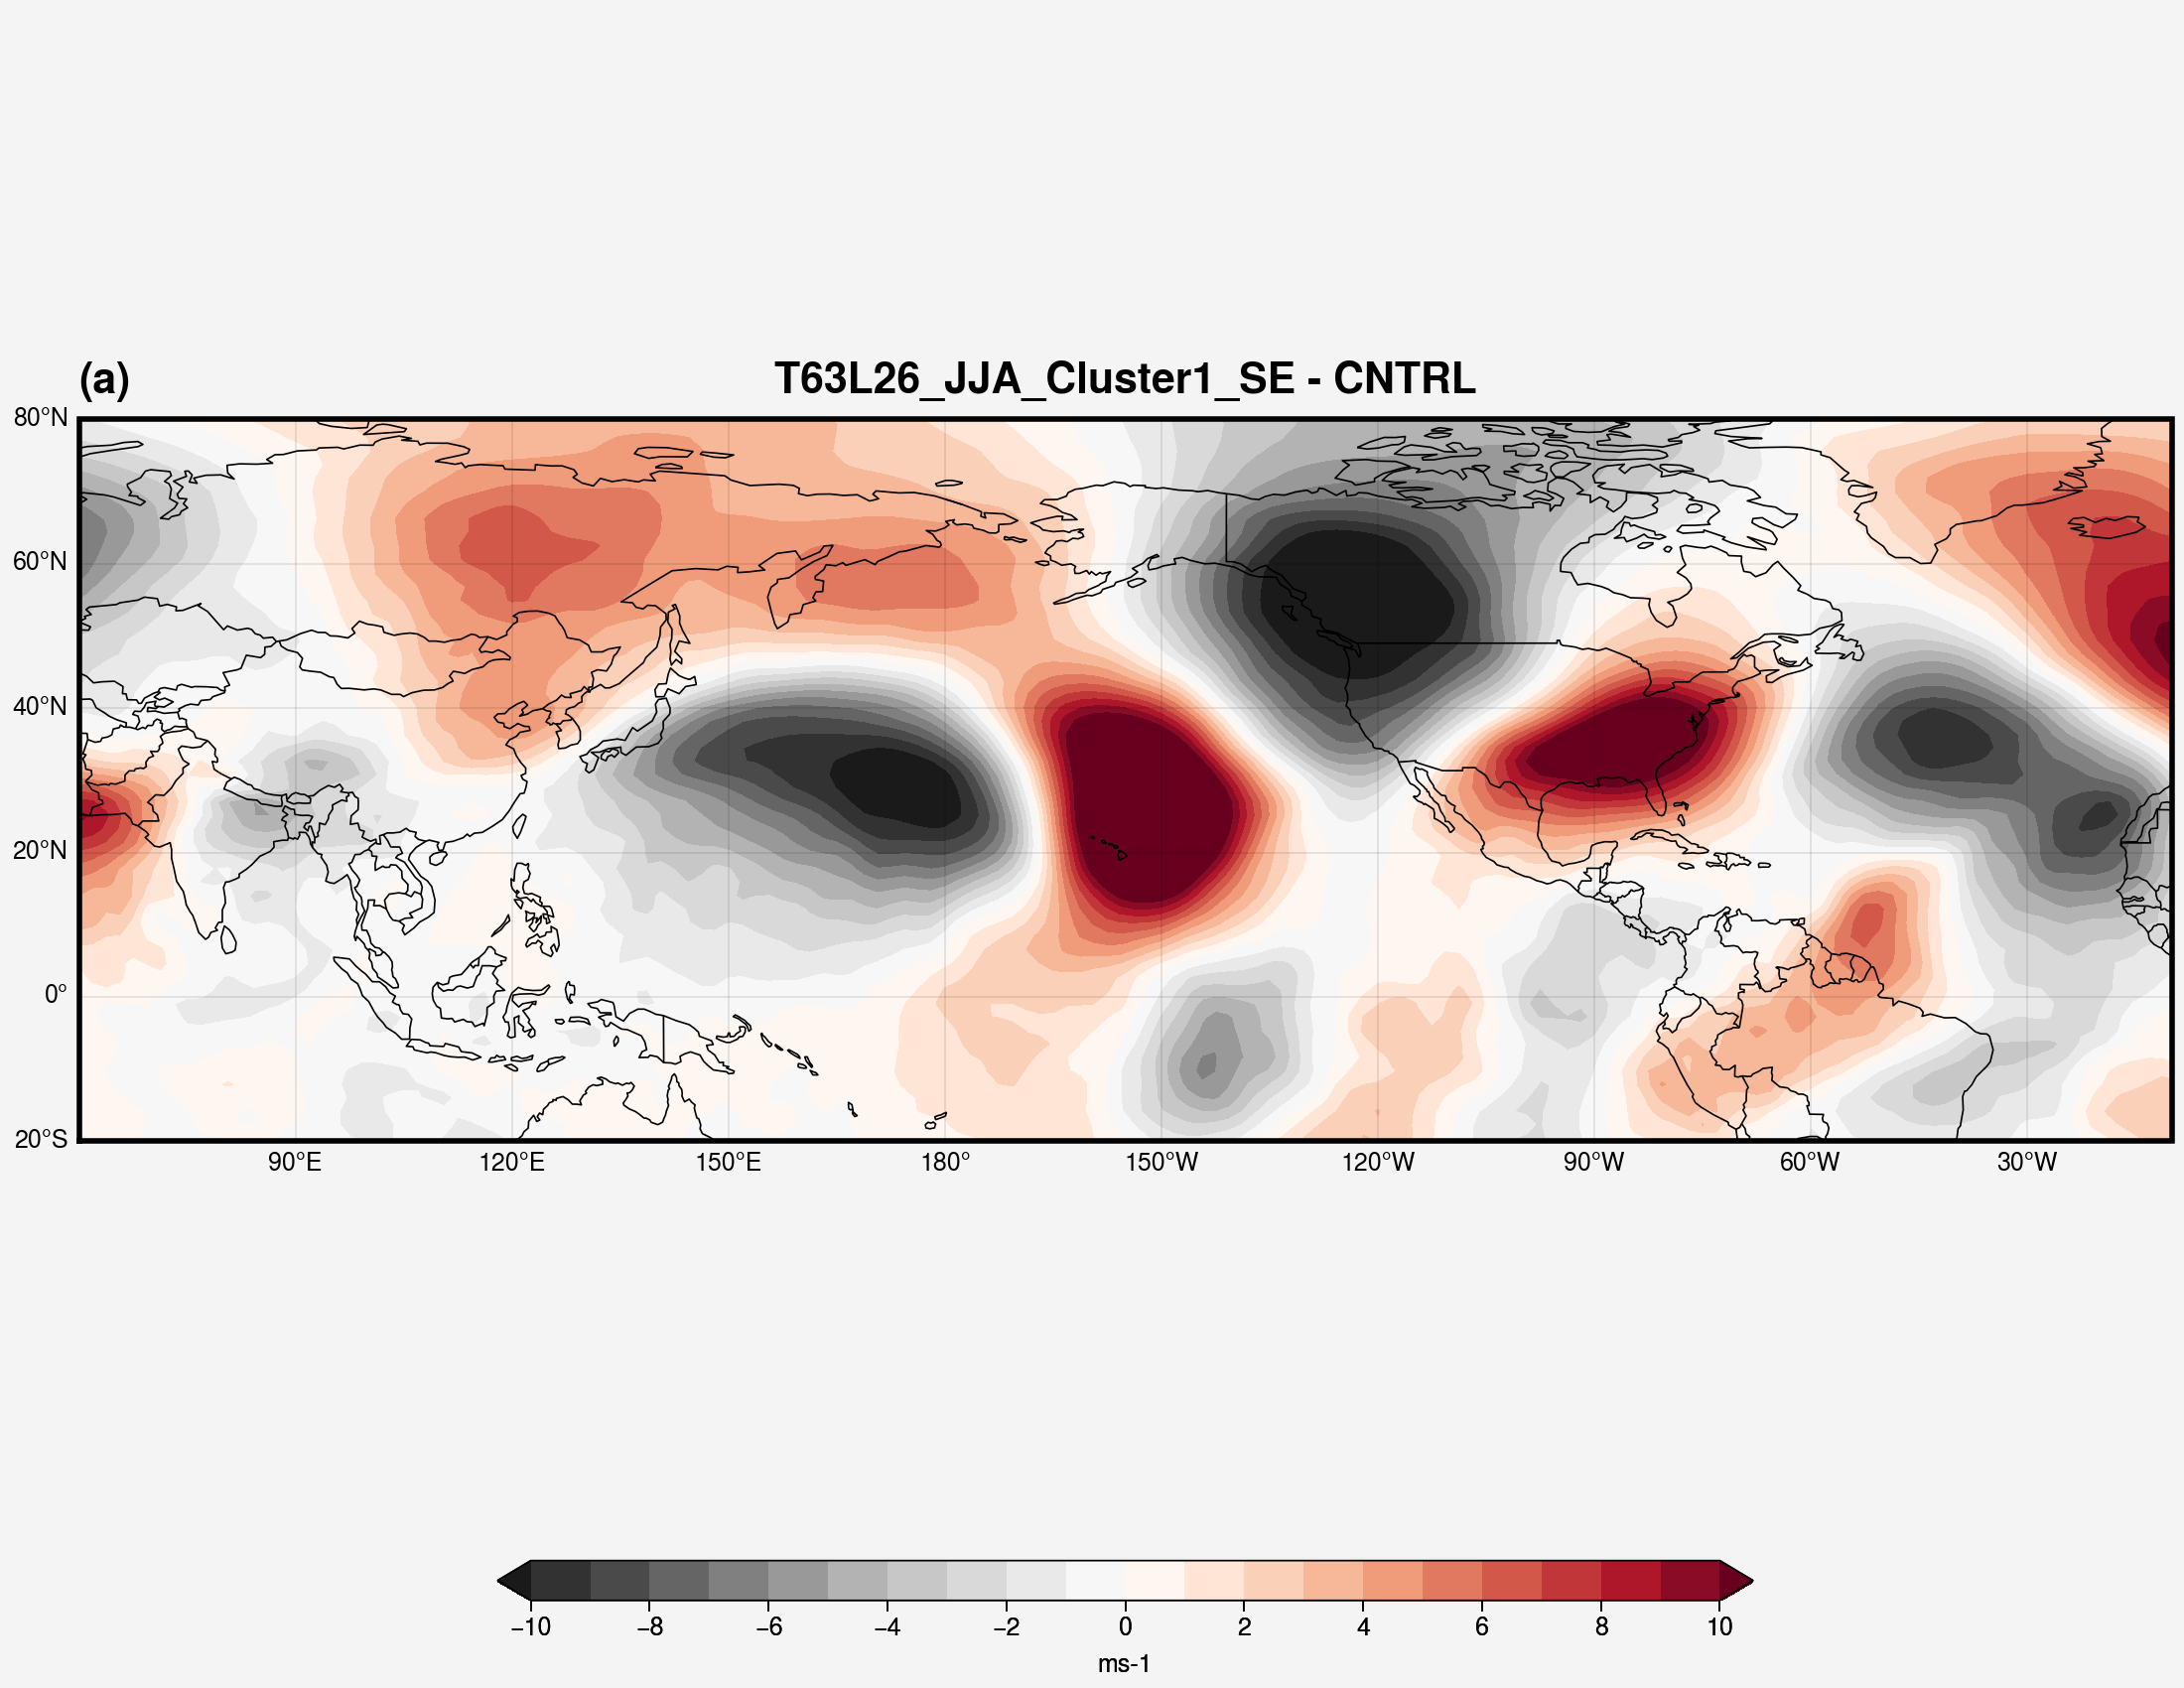

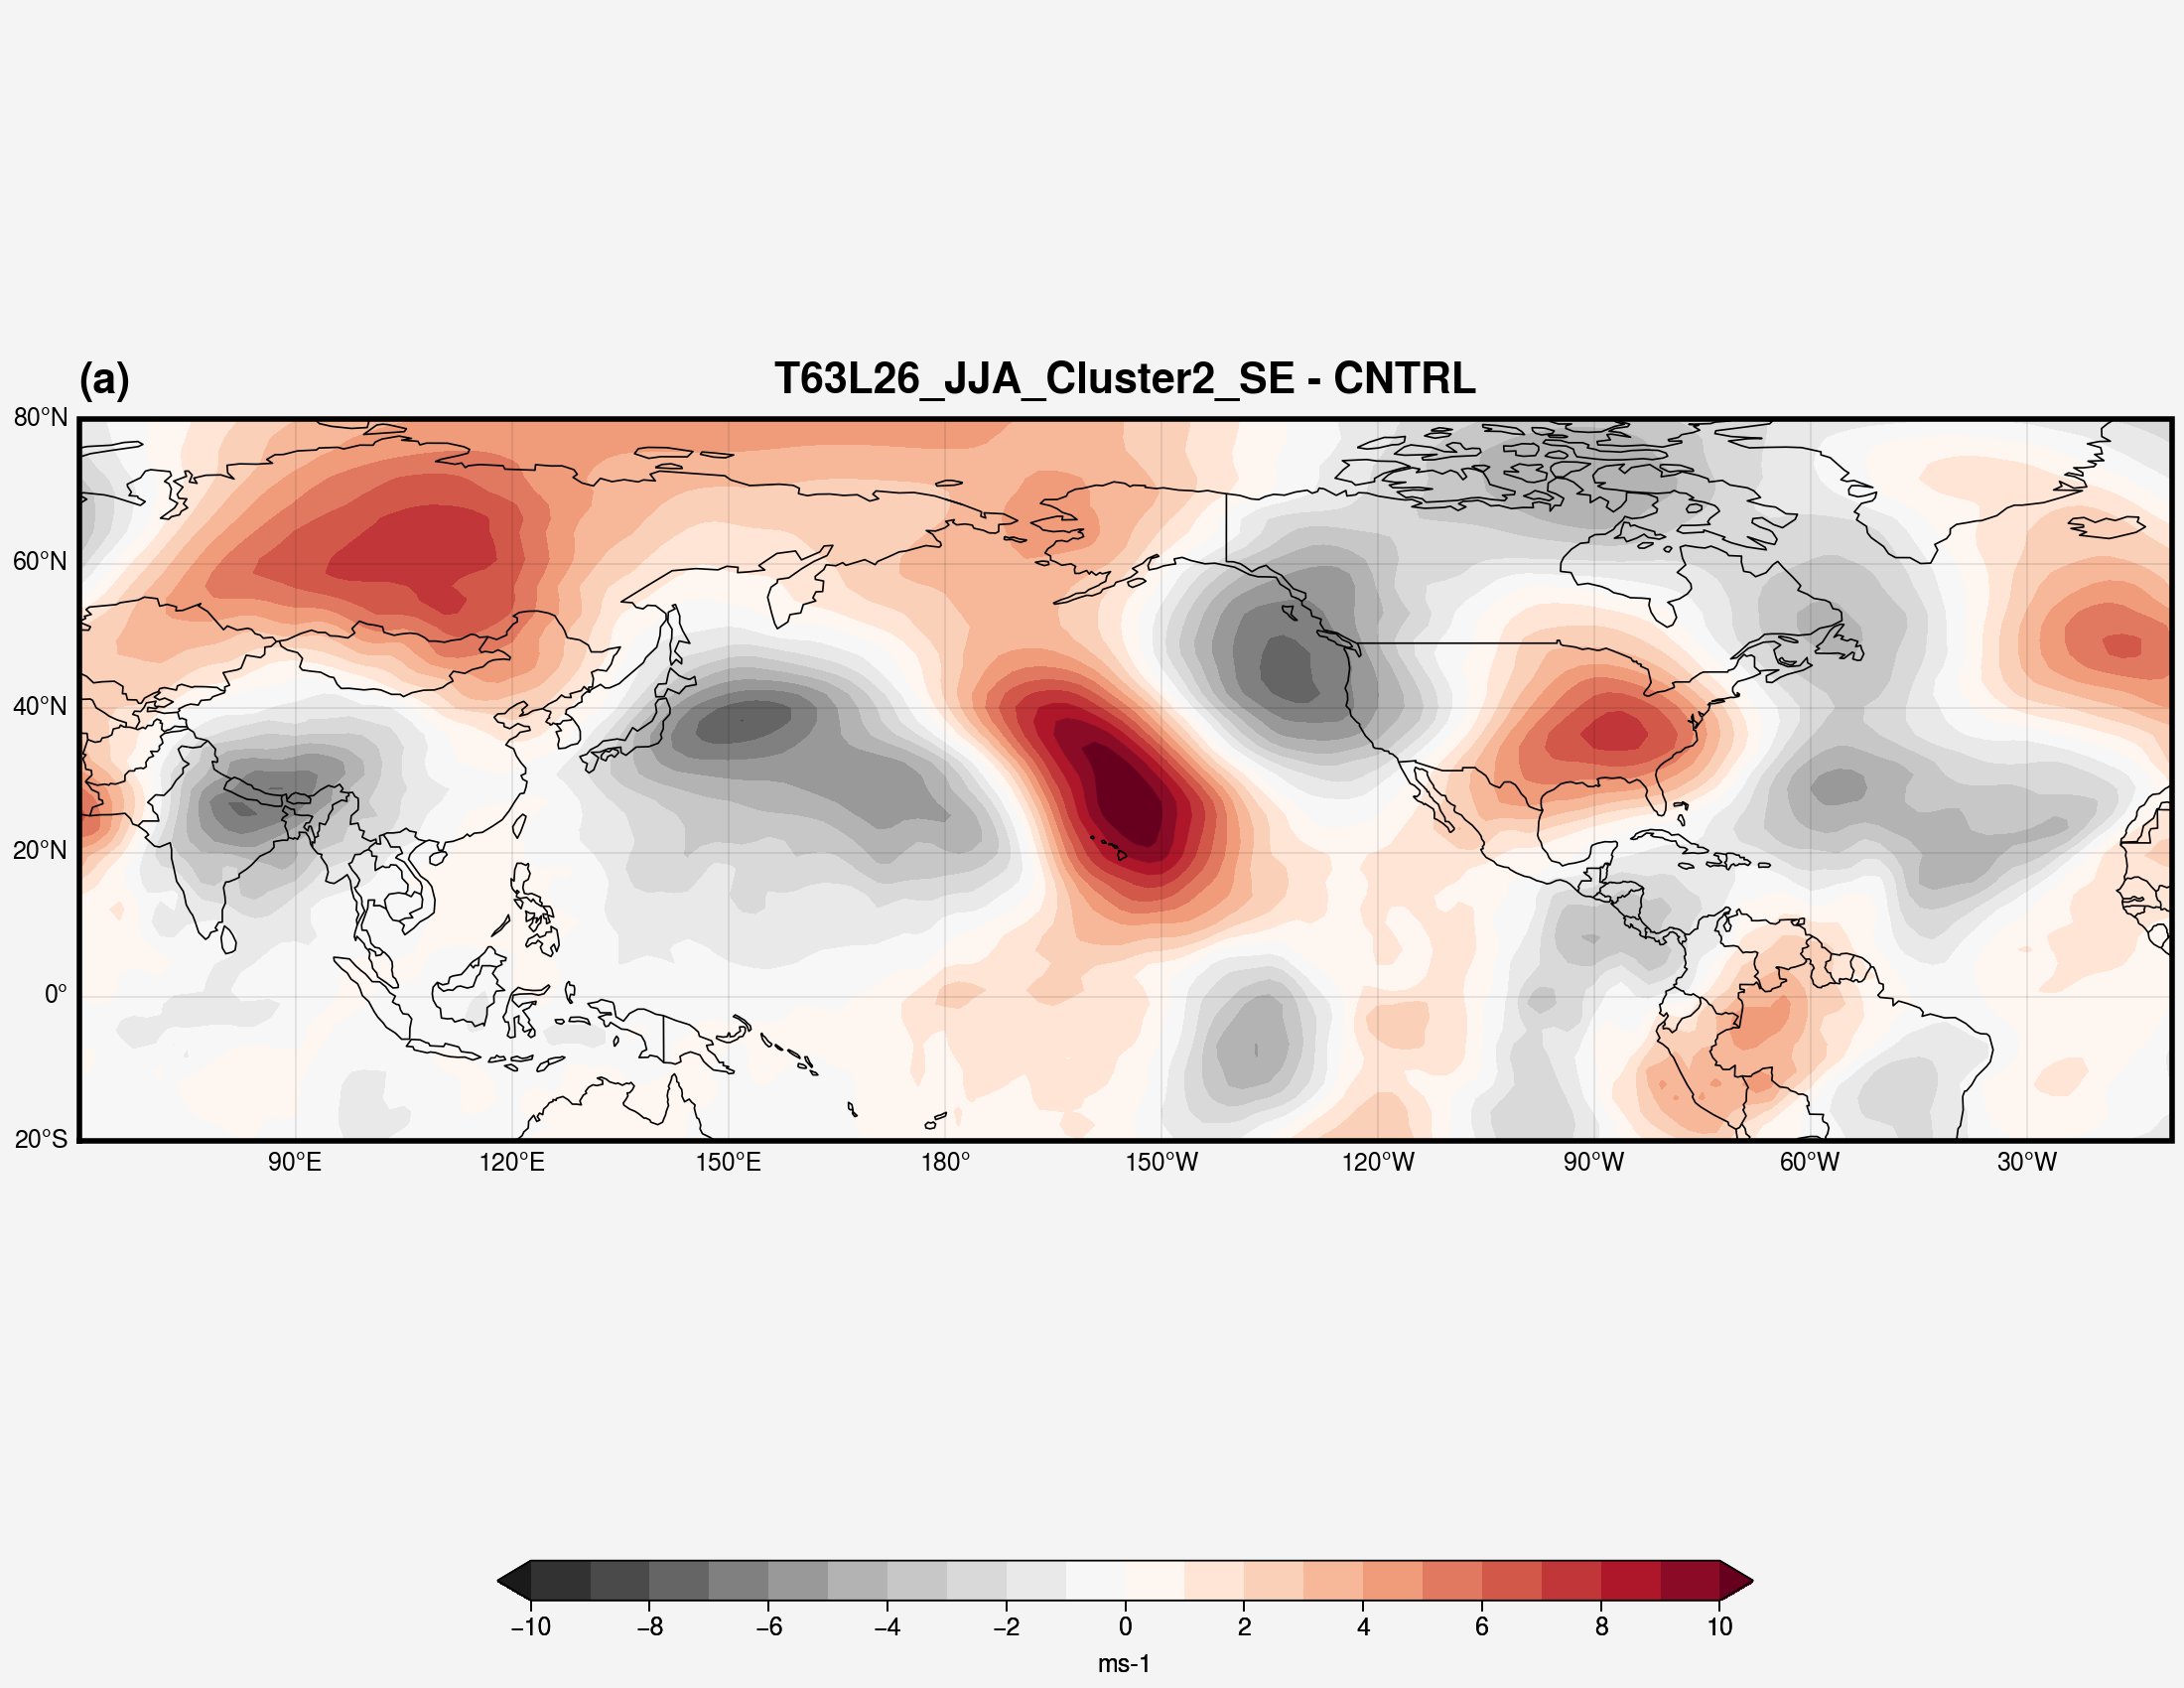

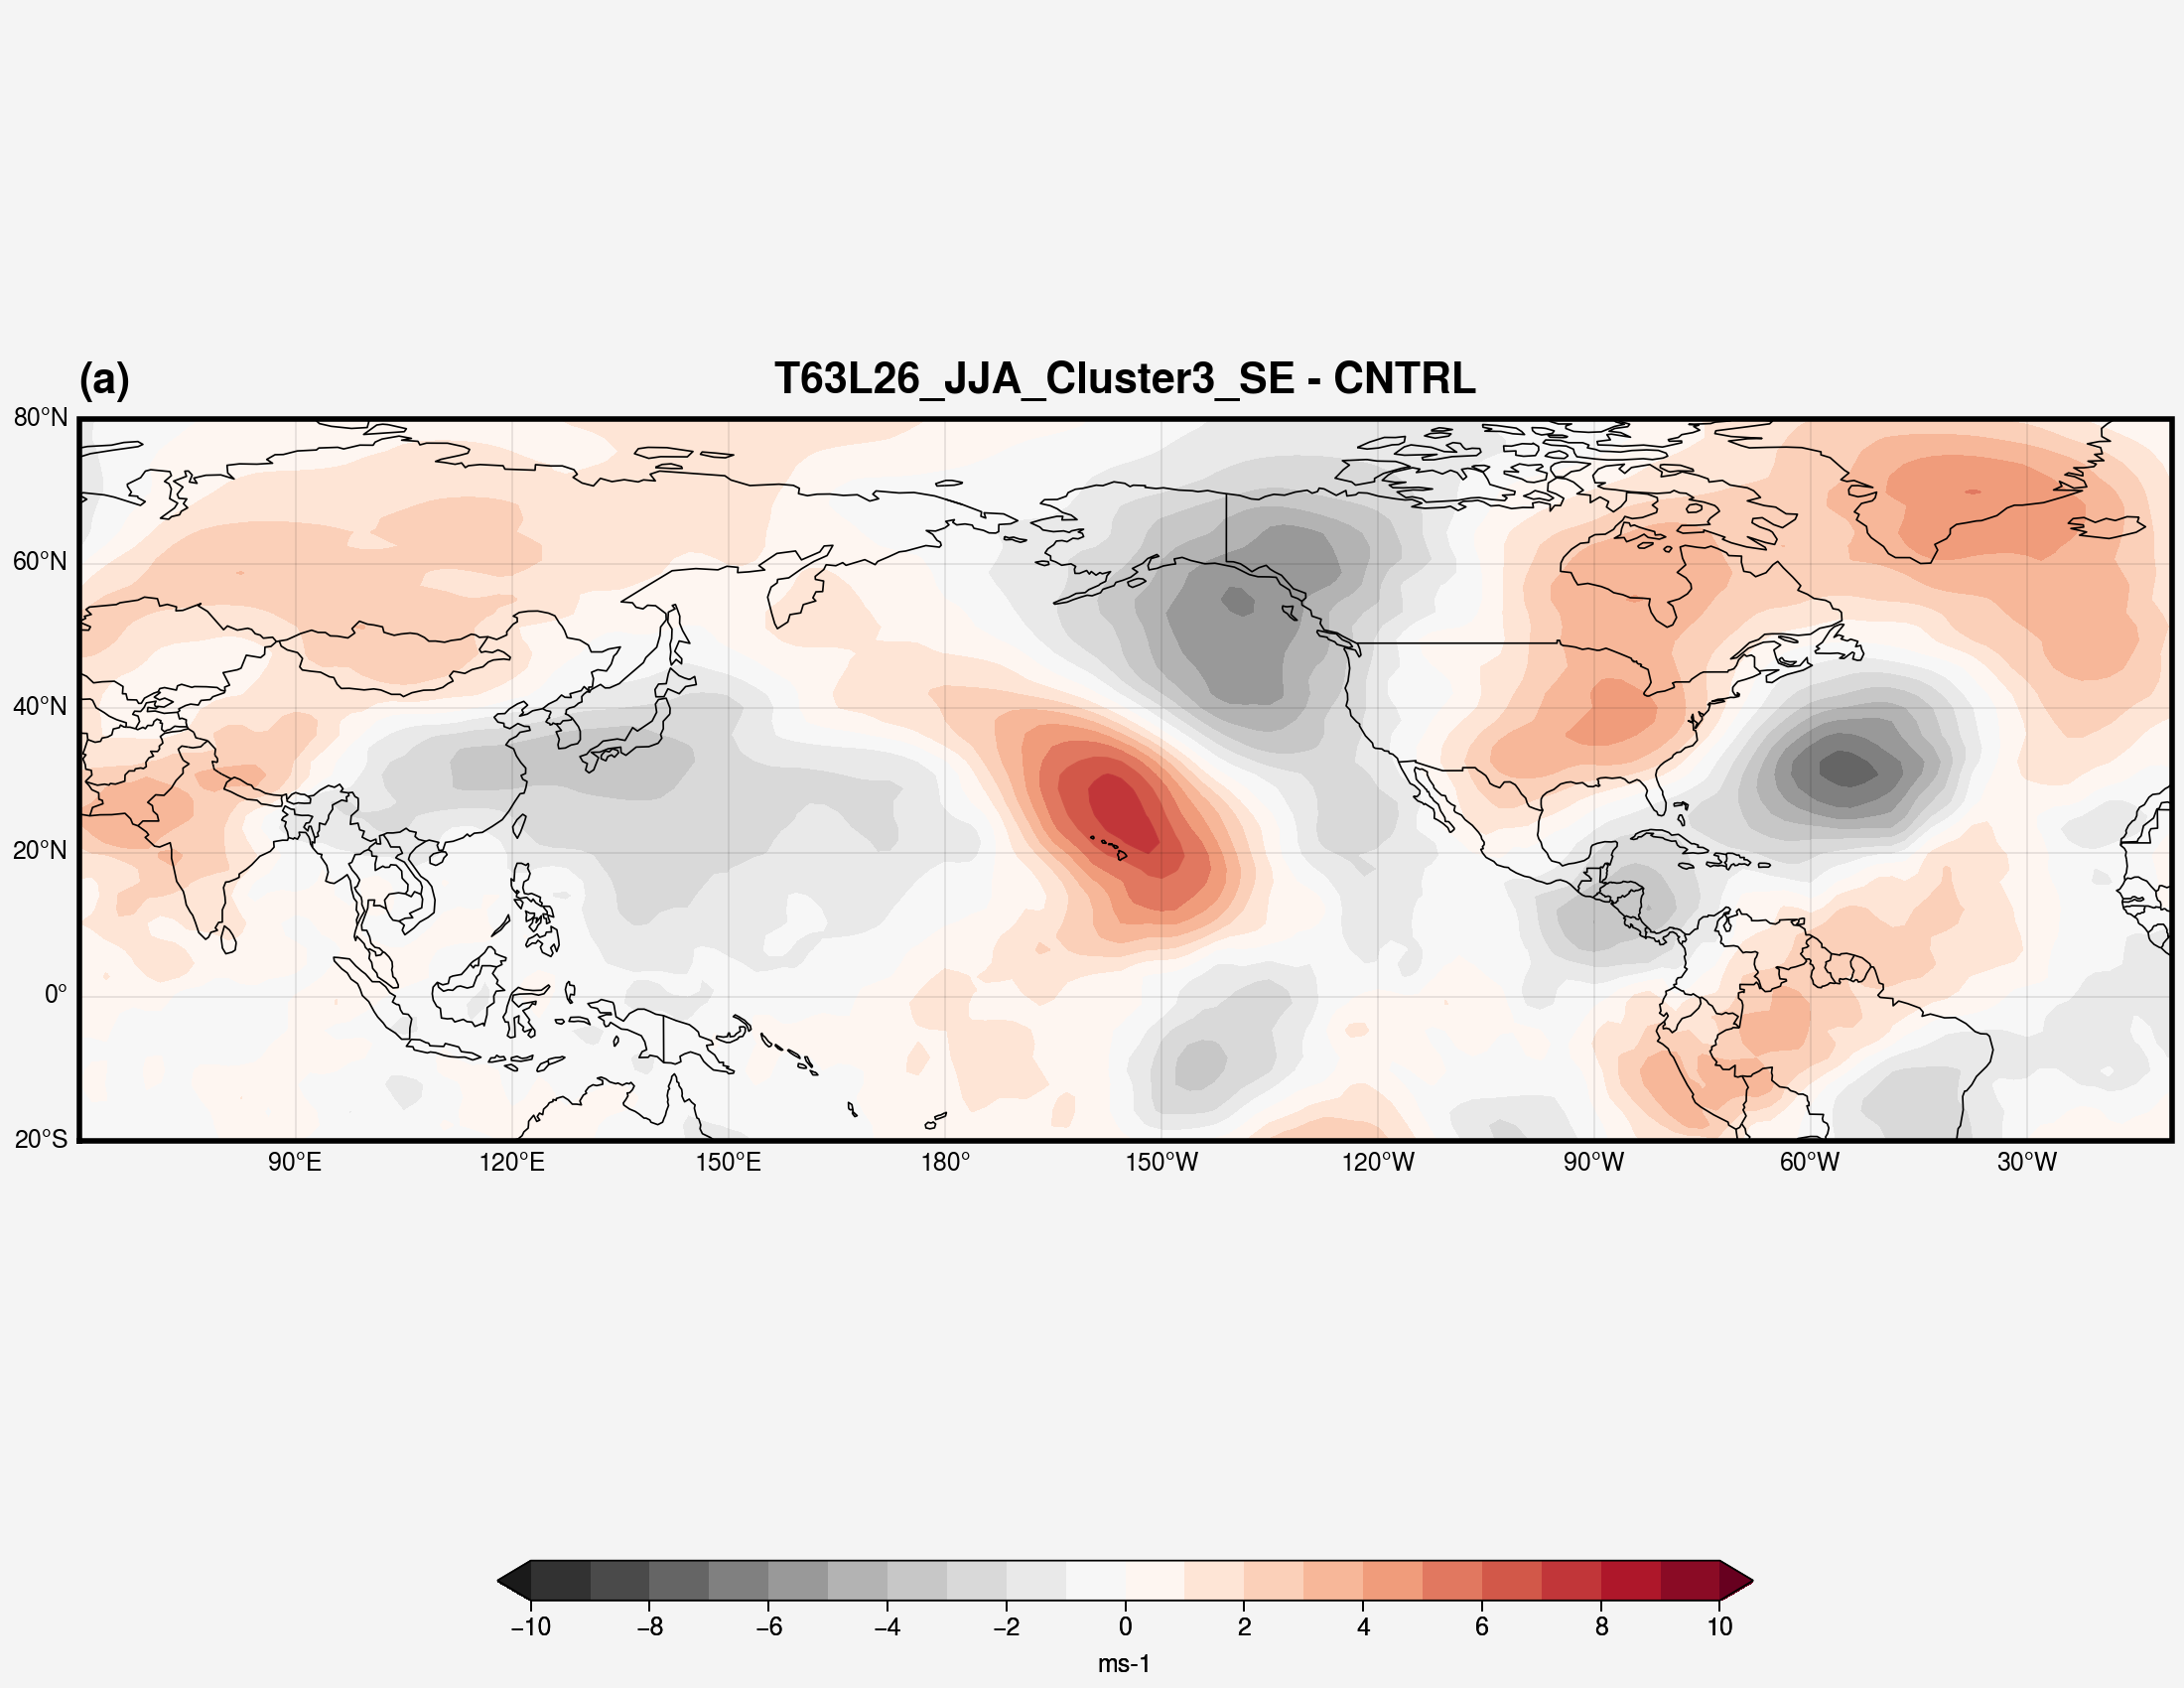

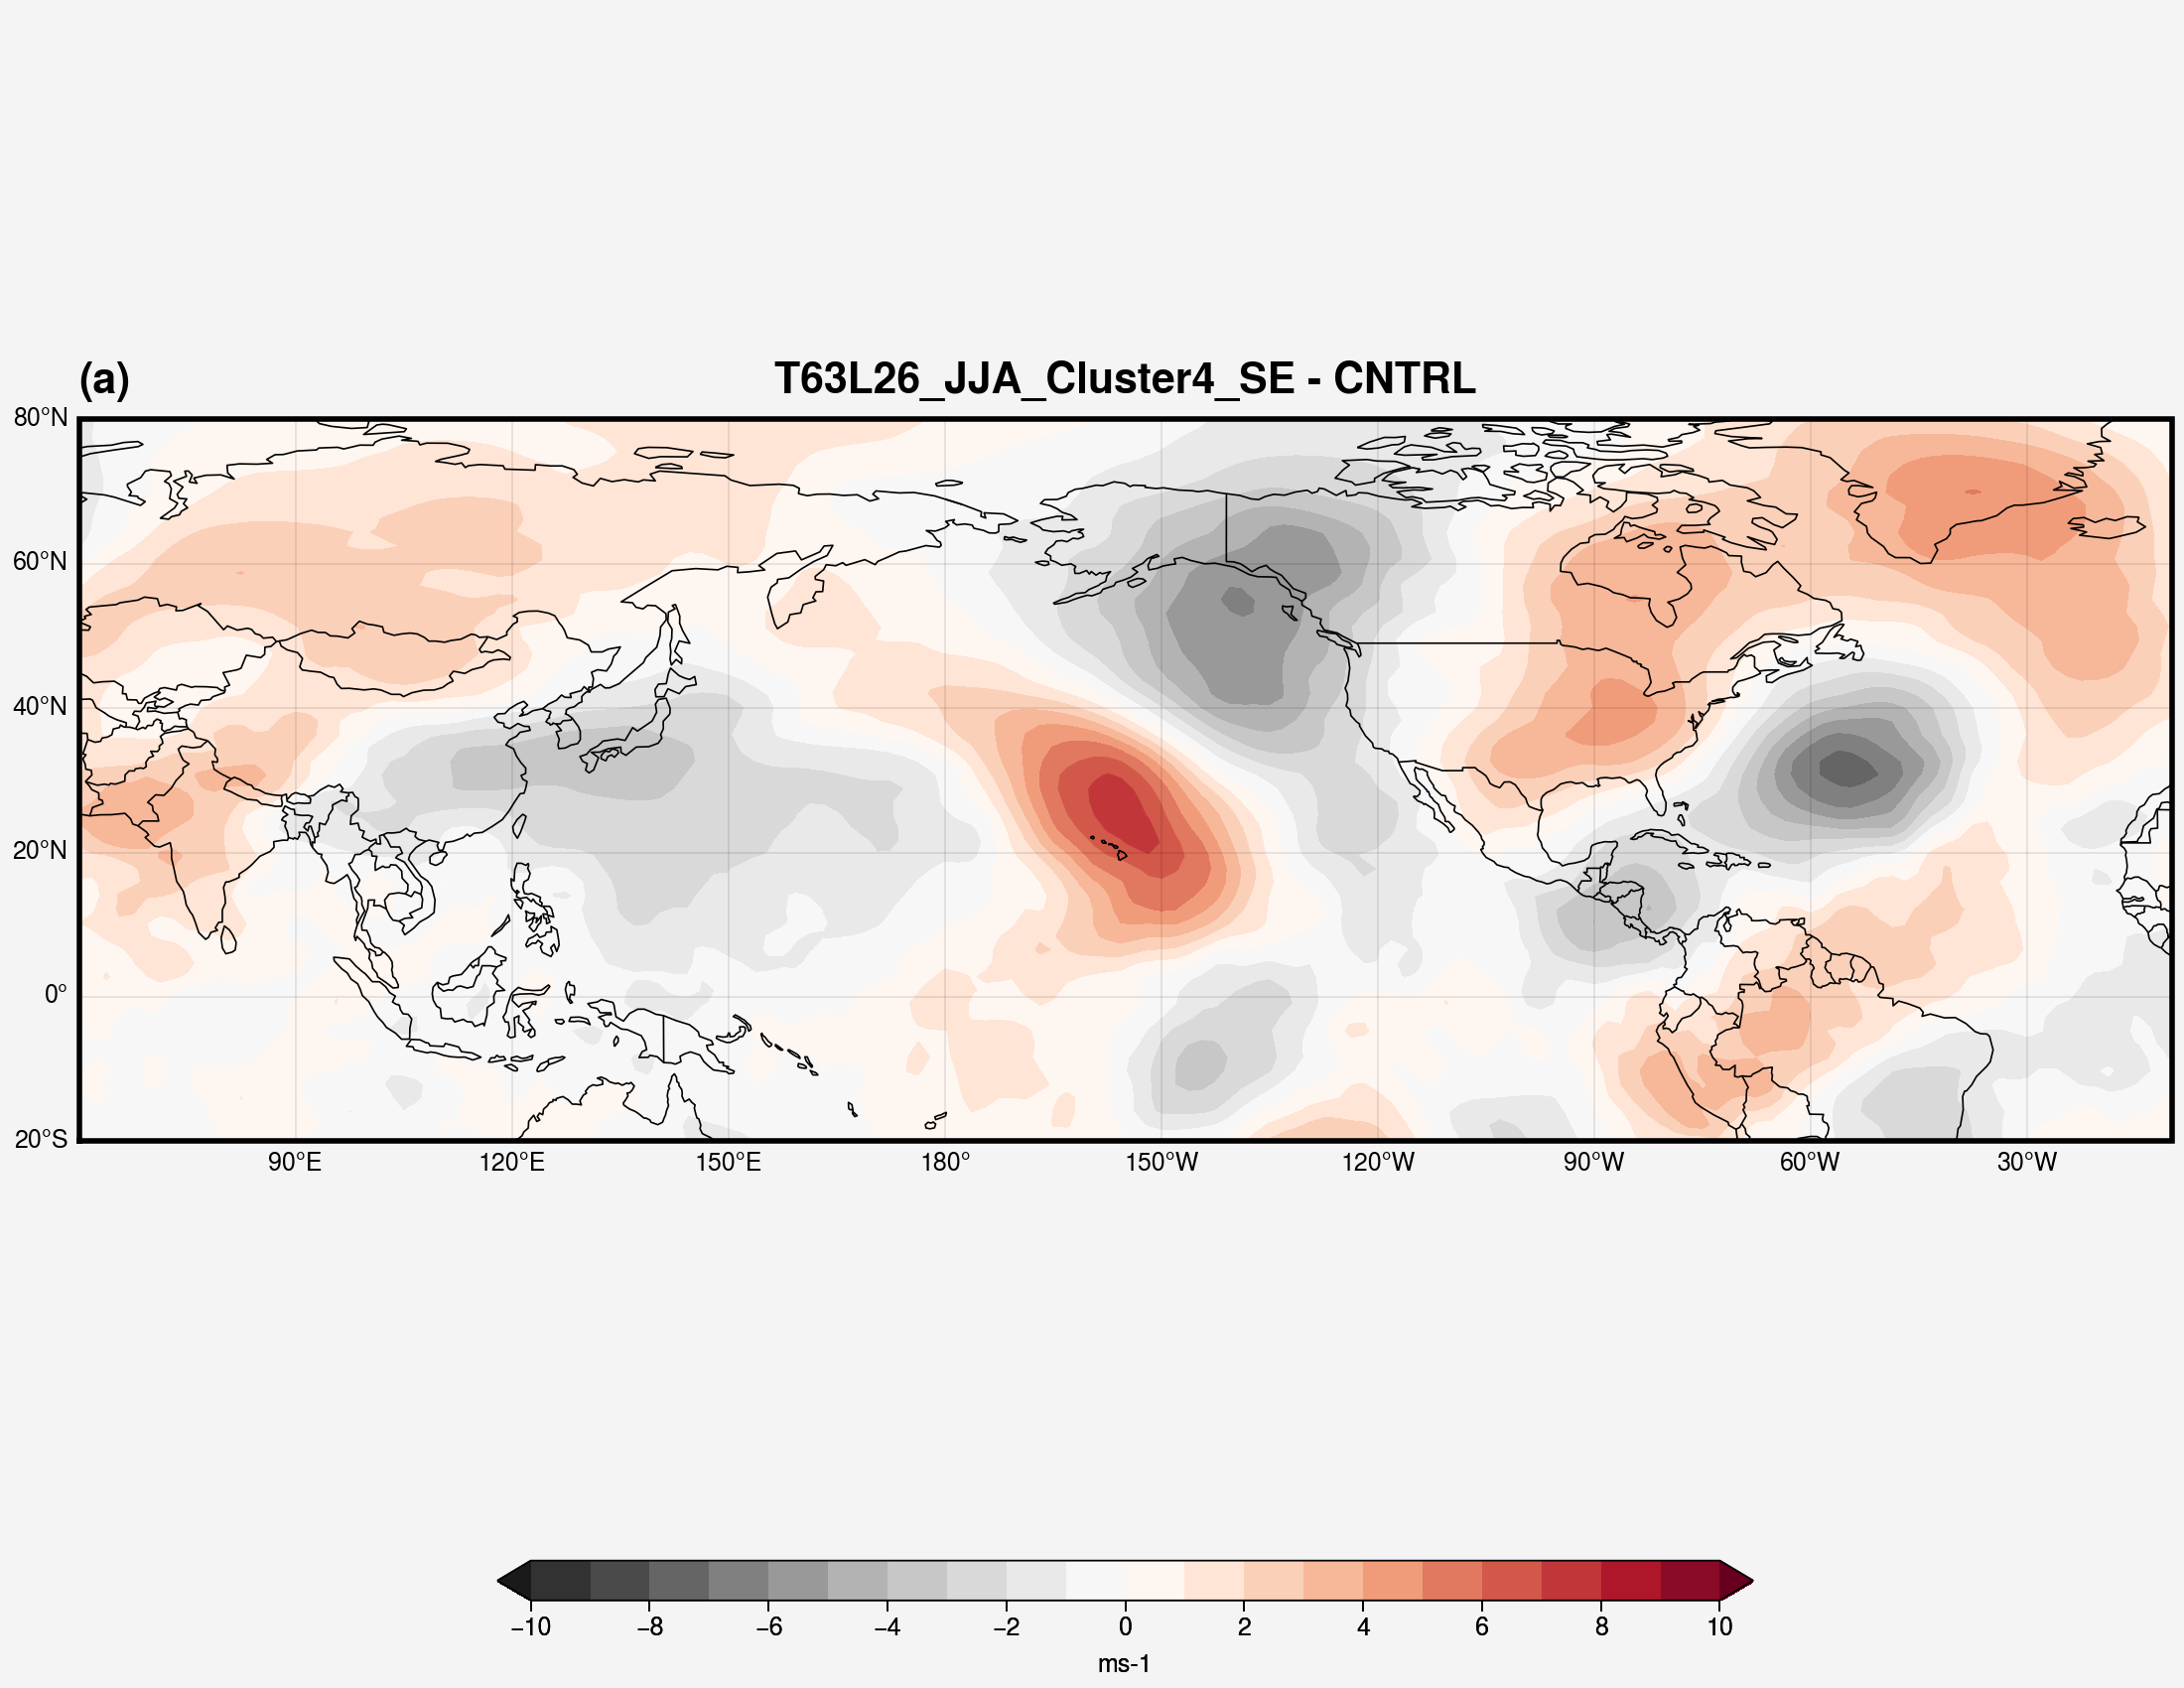

In [3]:
ds_cntrl=xr.open_mfdataset(basedir+cntrl_exp+'/vvel_Pressure_days_1-720.nc')

for exp in expnames:

    # Read in data
    print("Reading: " + basedir+exp+'/'+fname)
    ds_exp=xr.open_dataset(basedir+exp+'/'+fname)
    
    # Make means and diff
    ds_cntrl_mean=ds_cntrl.isel(time=slice(0,60)).mean(dim='time')
    ds_exp_mean=ds_exp.isel(time=slice(0,60)).mean(dim='time')
    ds_diff_v200=ds_exp_mean['v'].sel(lev=200.0)-ds_cntrl_mean['v'].sel(lev=200.0)

    # Plot diff
    nrows=1
    ncols=1
    #clevs=np.arange(-3,3.5,0.5)
    clevs=np.arange(-10,11,1)

    latreg=[-20,80]
    lonreg=[60,350]
    ccolor='RdGy_r'
    title=exp+' - CNTRL'


    f, axs = pplt.subplots(nrows=nrows, ncols=ncols, span=False, proj='pcarree',
                           proj_kw={'central_longitude': 210},
                           figsize=(11.0, 8.5),
                           sharex=False, sharey=False)
    axs.format(abcloc='l', abc='(a)',
               latlines=10,     # Draw latitude lines every 15°
               lonlines=30,     # Draw longitude lines every 30°
               latlabels=True,  # Show latitude labels
               lonlabels=True   # Show longitude labels
    )

    cs = axs.contourf(ds_diff_v200['lon'].values, ds_diff_v200['lat'].values,
                     ds_diff_v200.values,
                     norm='div', levels=clevs, cmap=ccolor, extend='both',
                     labels=False, labels_kw={'fontsize': 'large'})
    axs.format(
            title=title,
            reso='lo', coast=True, borders=True,
            coastcolor='black', borderscolor='black',
            innerborders=False, 
            latlim=latreg, lonlim=lonreg,
            lonlabels='b', latlabels='l',
            latlines=20, lonlines=30,
            grid=True,# to show gridlines
            fontsize=14,  # Larger title and labels
            titleweight='bold',  # Make the title bold
            labelweight='bold',  # Make axis labels bold
            linewidth=2,  # Make map frame bold
            )



    # Add colorbar at the bottom
    f.colorbar(cs, loc='b', length=0.6, label="ms-1")
